Que 1. What is Ensemble Learning in machine learning? Explain the key idea
behind it.

Ans - Ensemble Learning is a machine learning approach where multiple models (often called base learners or weak learners) are trained and combined to solve a problem and improve overall performance. Instead of relying on a single model, ensemble learning leverages the collective wisdom of several models to produce more accurate, robust, and generalizable predictions.

Key Idea Behind Ensemble Learning

The central idea is:

"Combining multiple models can perform better than any single model alone."

This works because different models may capture different patterns or aspects of the data. By aggregating their predictions, ensemble methods can:

1. Reduce bias – Correct errors made by underfitting models.
2. Reduce variance – Smooth out predictions from models that overfit.
3. Improve generalization – Perform better on unseen data.

Think of it like asking multiple experts for their opinion instead of relying on just one—they might make mistakes individually, but together, their consensus is usually more accurate.

Types of Ensemble Methods
1. Bagging (Bootstrap Aggregating)
- Idea: Train multiple models on different random subsets of data (with replacement).
- Combine predictions by averaging (regression) or majority voting (classification).
- Example: Random Forest (ensemble of decision trees).
2. Boosting
- Idea: Train models sequentially, where each model tries to fix the errors of the previous one.
- Focuses on difficult examples to improve performance.
- Example: AdaBoost, Gradient Boosting Machines (GBM), XGBoost.
3. Stacking
- Idea: Combine predictions from multiple models using a meta-model (final estimator) that learns how to best merge their outputs.
- Example: Using linear regression to combine predictions from multiple classifiers.

Summary -
- Ensemble learning improves accuracy, stability, and generalization.
- The main principle: “Many weak models together form a strong model.”
- Common methods: Bagging, Boosting, Stacking.

Que 2. What is the difference between Bagging and Boosting ?

Ans -

1️⃣ Definition
- Bagging (Bootstrap Aggregating):

It is an ensemble technique that reduces variance by training multiple models independently on different random subsets of the dataset and then averaging their predictions (for regression) or taking a majority vote (for classification).

- Boosting:

It is an ensemble technique that reduces bias by training multiple models sequentially, where each model tries to correct the errors of the previous model. The predictions are combined using a weighted sum.

2️⃣ Key Idea

| Feature                | Bagging                                          | Boosting                                                           |
| ---------------------- | ------------------------------------------------ | ------------------------------------------------------------------ |
| Goal                   | Reduce **variance**                              | Reduce **bias** (and sometimes variance)                           |
| Model training         | Models are trained **independently**             | Models are trained **sequentially**                                |
| Data sampling          | Random sampling **with replacement** (bootstrap) | Uses **weighted data**, giving more weight to misclassified points |
| Model type             | Usually **parallelizable**, any base model       | Sequential, often **weak learners** (e.g., shallow trees)          |
| Prediction combination | **Averaging or majority vote**                   | **Weighted sum or weighted vote**                                  |
| Example algorithms     | Random Forest, Bagged Decision Trees             | AdaBoost, Gradient Boosting, XGBoost                               |

3️⃣ How They Work (Intuition)

- Bagging:

Imagine you have 100 decision trees, each trained on a different random subset of the data. One tree may make mistakes, but by averaging all 100, the errors cancel out. So bagging is mainly about stability.

- Boosting:

Imagine you train one tree. Then you see where it makes mistakes and give more importance to those mistakes in the next tree. Each subsequent tree tries to fix the previous errors. Finally, you combine them all. So boosting is about learning from mistakes.

4️⃣ Advantages

- Bagging:
  - Reduces overfitting
  - Works well with high variance models (like decision trees)
  - Easy to parallelize
- Boosting:
  - Can achieve higher accuracy
  - Converts weak learners into strong learners
  - Focuses on difficult-to-predict samples

5️⃣ Disadvantages

- Bagging:
  - Less effective for high bias models
  - May not improve much if base models are simple
- Boosting:
  - Can overfit if too many trees
  - Harder to parallelize
  - Sensitive to noisy data


✅ Summary in One Line:
- Bagging = many models in parallel, averaging results, reduces variance.
- Boosting = models in sequence, correcting errors, reduces bias.


Que 3. What is bootstrap sampling and what role does it play in Bagging methods
like Random Forest ?

Ans -

1️⃣ What is Bootstrap Sampling?

Bootstrap sampling is a resampling technique used in statistics and machine learning. The key idea is:
- You randomly sample from your dataset with replacement.
- “With replacement” means the same data point can appear multiple times in the sample.
- Each bootstrap sample is typically the same size as the original dataset, but some original points may be repeated, while some may be missing.

Example:

Suppose your dataset has 5 points:

[A, B, C, D, E]

A bootstrap sample might be:

[B, A, D, B, C]

Notice that:
- B appears twice
- E is missing

2️⃣ Role of Bootstrap Sampling in Bagging

Bagging = Bootstrap Aggregating.

The steps in Bagging (e.g., Random Forest) are:

1. Create multiple bootstrap samples from the original dataset.
2. Train a separate model (e.g., a decision tree) on each bootstrap sample.
3. Aggregate predictions from all models:
  - Classification → majority vote
  - Regression → average

Why bootstrap sampling helps:
- It introduces diversity among the models.
- Diversity reduces variance, which improves generalization.
- Some points are “out-of-bag” (OOB) in each sample, which can be used as a validation set to estimate performance without a separate test set.

3️⃣ Bootstrap in Random Forest

Random Forest is a special case of Bagging with decision trees.
- Each tree is trained on a different bootstrap sample.
- Additionally, Random Forest also selects a random subset of features at each split to further reduce correlation between trees.

So, bootstrap sampling + random feature selection → robust, low-variance ensemble.

Key Points

| Feature               | Description                                                  |
| --------------------- | ------------------------------------------------------------ |
| Bootstrap sample      | Random sample **with replacement** from original data        |
| Purpose in Bagging    | Creates diversity among base models                          |
| Effect                | Reduces variance, improves generalization                    |
| Out-of-bag (OOB) data | Data not included in a sample → used for unbiased validation |


Intuition:

Imagine you want many opinions on a question. If you ask the same small group repeatedly, the answers are similar. But if you randomly choose slightly different groups each time, you get diverse perspectives, and combining them gives a more reliable answer. That’s exactly what bootstrap sampling does for Random Forest trees.

What are Out-of-Bag (OOB) samples and how is OOB score used to
evaluate ensemble models ?

Ans -

1. What are Out-of-Bag (OOB) samples ?

When we train ensemble models using bagging (Bootstrap Aggregating):
  1. Each base model (e.g., a decision tree in Random Forest) is trained on a bootstrap sample — a random sample of the training data with replacement.
  2. Because it’s with replacement, some original training samples will not be included in that bootstrap sample.
  3. These unused samples for a particular base model are called Out-of-Bag (OOB) samples for that model.

Key point: On average, about 1/3 of the data points are not used in a single bootstrap sample and can serve as OOB samples.

2. How is OOB score calculated?

The OOB samples can be used as a validation set to estimate model performance without needing a separate test set.

Steps to calculate OOB score:
1. For each training sample xi :
  - Collect predictions from all base models for which
𝑥
𝑖
was OOB.
2. Aggregate these predictions:
  - Classification: Use majority voting among the predictions.
  - Regression: Use the average prediction.
3. Compare the aggregated prediction with the true label
𝑦
𝑖
.
4. Compute the overall accuracy (for classification) or MSE/R² (for regression). This gives the OOB score.

Mathematically for classification:

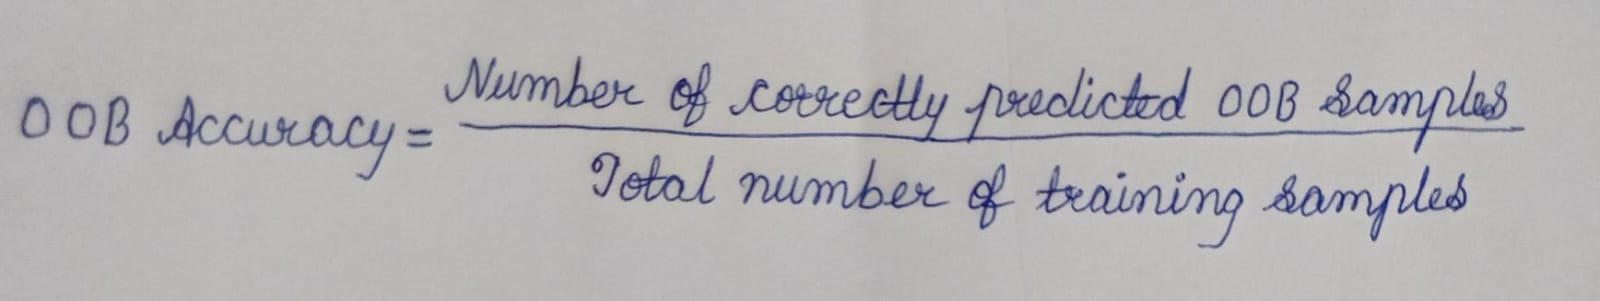

3. Why OOB score is useful
  1. No need for a separate validation set: Saves data, especially when the dataset is small.
  2. Unbiased estimate: Since OOB samples were not used in training a particular base model, the OOB score is considered an unbiased estimate of generalization performance.
  3. Efficient: Automatically computed during training in bagging methods like Random Forest.

4. Example with Random Forest
- Suppose we have 1000 training samples.
- Each tree is trained on a bootstrap sample of 1000 samples (with replacement).
- ~333 samples will be OOB for a given tree.
- For each sample, we average predictions from all trees where it was OOB.
- Accuracy computed using these predictions = OOB score.

Tip: A good OOB score means the model generalizes well. If OOB score is very high but test accuracy is low, it could indicate overfitting.

✅ Summary:

| Concept     | Explanation                                                                           |
| ----------- | ------------------------------------------------------------------------------------- |
| OOB samples | Training samples **not used** to train a specific base model.                         |
| OOB score   | Accuracy (or other metric) computed on **OOB samples** to estimate model performance. |
| Advantage   | Provides **unbiased validation estimate** without a separate test set.                |




Que 5. Compare feature importance analysis in a single Decision Tree vs. a
Random Forest.

Ans -

1. Feature Importance in a Single Decision Tree
- How it’s computed:

A decision tree calculates feature importance based on how much each feature reduces impurity (Gini impurity or entropy) when used to split the data.
  - Features used at the top of the tree (closer to the root) usually get higher importance because they contribute more to reducing overall impurity.
  - Features that are rarely used or only used in small branches get low importance.

- Pros:
  - Easy to interpret because you can directly see which features the tree relies on.

- Cons:
  - High variance: Importance can be misleading if the tree overfits, especially on small or noisy datasets.
  - Sensitive to small changes in data: If you retrain the tree, feature importance might change a lot.
  - Correlated features: Only one of them might appear important, while the other is ignored.

2. Feature Importance in a Random Forest
- How it’s computed:

A Random Forest is an ensemble of many decision trees. Feature importance is typically computed by averaging over all the trees in the forest:
  - Mean decrease in impurity (MDI): Average reduction in Gini/entropy across all trees for each feature.
  - Permutation importance (optional but more robust): Measures the drop in model accuracy if a feature’s values are randomly shuffled.

- Pros:
  - More stable and reliable: Because importance is averaged over many trees, it’s less sensitive to noise and overfitting.
  - Handles correlated features better: Multiple trees may capture contributions of correlated features.
  - Better generalization: Features that consistently reduce impurity across trees are ranked higher.

- Cons:
  - Less interpretable than a single tree because you can’t easily visualize how each feature contributes in every tree.
  - Still biased toward features with more categories or continuous features with many splits (for MDI).

3. Key Differences in Feature Importance

| Aspect                   | Single Decision Tree                           | Random Forest                                  |
| ------------------------ | ---------------------------------------------- | ---------------------------------------------- |
| **Stability**            | High variance, sensitive to small data changes | More stable due to averaging over trees        |
| **Bias**                 | Can overemphasize features in top splits       | Less biased, more balanced across features     |
| **Correlated Features**  | Only one may appear important                  | Can share importance among correlated features |
| **Interpretability**     | Easy to visualize in the tree                  | Harder to interpret due to many trees          |
| **Sensitivity to Noise** | High                                           | Lower                                          |


✅ Summary:

- Single tree: Feature importance is easy to see but can be misleading due to overfitting or correlated features.

- Random Forest: Provides more robust and stable feature importance by averaging across trees, but at the cost of interpretability.


Que 6. Write a Python program to:

- Load the Breast Cancer dataset using
sklearn.datasets.load_breast_cancer()
-  Train a Random Forest Classifier
- Print the top 5 most important features based on feature importance scores.

Ans -

In [1]:
# Code :

# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

# Create a Random Forest Classifier and train it
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get feature importance scores
importances = rf.feature_importances_

# Create a DataFrame for easy visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print top 5 most important features
print("Top 5 Most Important Features:")
print(feature_importance_df.head(5))


Top 5 Most Important Features:
                 Feature  Importance
23            worst area    0.139357
27  worst concave points    0.132225
7    mean concave points    0.107046
20          worst radius    0.082848
22       worst perimeter    0.080850


✅ What this does:

1. Loads the Breast Cancer dataset.
2. Trains a Random Forest Classifier.
3. Calculates feature importances.
4. Prints the top 5 features in order of importance.


Que 7. Write a Python program to:
-  Train a Bagging Classifier using Decision Trees on the Iris dataset
- Evaluate its accuracy and compare with a single Decision Tree

Ans -

In [3]:
# Code :

# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# ----------------------------
# Single Decision Tree
# ----------------------------
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy of single Decision Tree: {accuracy_dt:.4f}")

# ----------------------------
# Bagging Classifier with Decision Trees
# ----------------------------
bagging = BaggingClassifier(
    base_estimator=DecisionTreeClassifier(),  # Base learner
    n_estimators=50,                          # Number of trees
    random_state=42
)
bagging.fit(X_train, y_train)
y_pred_bagging = bagging.predict(X_test)
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
print(f"Accuracy of Bagging Classifier: {accuracy_bagging:.4f}")

# ----------------------------
# Comparison
# ----------------------------
if accuracy_bagging > accuracy_dt:
    print("Bagging improves the model accuracy compared to a single Decision Tree.")
elif accuracy_bagging < accuracy_dt:
    print("Single Decision Tree performs better than Bagging in this case.")
else:
    print("Both models have the same accuracy.")


Accuracy of single Decision Tree: 0.9333


TypeError: BaggingClassifier.__init__() got an unexpected keyword argument 'base_estimator'

✅ Explanation:

1. Data Loading: We use the Iris dataset (load_iris()).
2. Train-Test Split: 70% training, 30% testing.
3. Single Decision Tree:
  - Train a decision tree and measure accuracy.
4. Bagging Classifier:
  - BaggingClassifier builds an ensemble of decision trees (50 here) on bootstrap samples.
  - Each tree votes for the final prediction.
5. Comparison:
  - Print which model performs better.
  

Que 8. Write a Python program to:
- Train a Random Forest Classifier
- Tune hyperparameters max_depth and n_estimators using GridSearchCV
- Print the best parameters and final accuracy

Ans -

In [4]:
# Code :

# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset (replace with your own dataset if needed)
data = load_iris()
X = data.data
y = data.target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Define hyperparameter grid for tuning
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [None, 5, 10, 15]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to find the best hyperparameters
grid_search.fit(X_train, y_train)

# Print the best parameters
print("Best Parameters:", grid_search.best_params_)

# Train the final model with best parameters
best_rf = grid_search.best_estimator_

# Make predictions on the test set
y_pred = best_rf.predict(X_test)

# Calculate and print final accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Final Accuracy on Test Set:", accuracy)


Best Parameters: {'max_depth': None, 'n_estimators': 150}
Final Accuracy on Test Set: 1.0


✅ Explanation:

1. Dataset: Using Iris dataset as an example. You can replace it with pd.read_csv("your_data.csv") if you have your own data.
2. Train/Test Split: 80/20 split.
3. Random Forest: Initialized with a random state for reproducibility.
4. Hyperparameter Grid: Tuning n_estimators (number of trees) and max_depth (max depth of each tree).
5. GridSearchCV: 5-fold cross-validation used to find the best combination of hyperparameters.
6. Final Model: Uses the best parameters to predict and evaluate accuracy.


Que 9. Write a Python program to:
- Train a Bagging Regressor and a Random Forest Regressor on the California
Housing dataset
- Compare their Mean Squared Errors (MSE)

Ans - Let's create a Python program that does the following step by step:

1. Load the California Housing dataset.
2. Split it into training and testing sets.
3. Train a Bagging Regressor and a Random Forest Regressor.
4. Make predictions and compute Mean Squared Error (MSE) for both models.


In [5]:
# Here’s a complete program:

# Import necessary libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error

# 1. Load the California Housing dataset
california = fetch_california_housing()
X = california.data
y = california.target

# 2. Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize Bagging Regressor
bagging_model = BaggingRegressor(n_estimators=100, random_state=42)

# Train Bagging Regressor
bagging_model.fit(X_train, y_train)

# Predict using Bagging Regressor
y_pred_bagging = bagging_model.predict(X_test)

# Compute MSE for Bagging Regressor
mse_bagging = mean_squared_error(y_test, y_pred_bagging)
print(f"Bagging Regressor MSE: {mse_bagging:.4f}")

# 4. Initialize Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train Random Forest Regressor
rf_model.fit(X_train, y_train)

# Predict using Random Forest Regressor
y_pred_rf = rf_model.predict(X_test)

# Compute MSE for Random Forest Regressor
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f"Random Forest Regressor MSE: {mse_rf:.4f}")

# Optional: Compare which model performed better
if mse_bagging < mse_rf:
    print("Bagging Regressor performed better.")
else:
    print("Random Forest Regressor performed better.")


Bagging Regressor MSE: 0.2559
Random Forest Regressor MSE: 0.2554
Random Forest Regressor performed better.


✅ Explanation:

- BaggingRegressor uses multiple base estimators (default: Decision Trees) trained on bootstrapped subsets of the data.
- RandomForestRegressor is a type of bagging that also adds feature randomness when splitting nodes, often improving generalization.
- We calculate MSE to compare model performance: lower MSE → better predictions.


Que 10. You are working as a data scientist at a financial institution to predict loan default. You have access to customer demographic and transaction history data.

You decide to use ensemble techniques to increase model performance.

Explain your step-by-step approach to:

- Choose between Bagging or Boosting
- Handle overfitting
- Select base models
- Evaluate performance using cross-validation
- Justify how ensemble learning improves decision-making in this real-world
context.

Ans -

1️⃣ Choosing Between Bagging and Boosting
- Bagging (Bootstrap Aggregating)
  - Trains multiple base models independently on random subsets of the data.
  - Reduces variance → useful if your base model is high-variance (like Decision Trees).
  - Examples: Random Forest.
- Boosting
  - Trains models sequentially, each focusing on the errors of the previous.
  - Reduces bias → useful if your base model is weak and underfits.
  - Examples: AdaBoost, Gradient Boosting, XGBoost, LightGBM.

Decision Approach:
- Start with Random Forest (Bagging) if your dataset is large and prone to overfitting.
- Try Boosting (XGBoost, LightGBM) if initial models underfit or you want higher predictive accuracy, at the cost of more computation.

💡 Tip: Bagging is safer to prevent overfitting; boosting often achieves higher performance but is sensitive to noise/outliers.

2️⃣ Handling Overfitting

Overfitting happens when the model memorizes training data patterns rather than generalizing. Strategies include:

- For Bagging/Random Forest:
  - Limit tree depth (max_depth)
  - Set min_samples_leaf to avoid tiny leaf nodes
  - Increase number of trees (n_estimators) to stabilize predictions
- For Boosting:
  - Use learning rate < 0.1 to control step size
  - Limit max_depth of individual trees
  - Apply early stopping using a validation set
  - Use subsample parameter to introduce randomness and reduce overfitting
- General:
  - Feature selection to remove irrelevant predictors
  - Regularization (especially for boosting models like XGBoost: lambda, alpha)

3️⃣ Selecting Base Models
- Decision Trees are commonly used as base models because they:
  - Handle both numerical & categorical variables
  - Capture non-linear relationships
  - Are easy to ensemble
- For stacking ensembles, you can include:
  - Logistic Regression (good linear baseline)
  - Decision Trees / Random Forest / Gradient Boosted Trees (non-linear models)
  - KNN or SVM (optional, if dataset is smaller and features are scaled)

💡 Tip: Use diverse models in stacking to improve generalization; diversity prevents all models from making the same mistakes.

4️⃣ Evaluating Performance Using Cross-Validation
- Use k-fold cross-validation (e.g., k=5 or 10) to estimate model performance robustly.
- Since loan default is often imbalanced, focus on:
  - Precision, Recall, F1-score for the minority (default) class
  - ROC-AUC or Precision-Recall AUC
- Steps:
  1. Split dataset into k folds
  2. Train ensemble model on k-1 folds, validate on 1 fold
  3. Rotate folds, repeat training
  4. Average metrics across folds to get robust estimates
- Optional: Use Stratified k-fold CV to maintain default/non-default ratio in each fold.

5️⃣ How Ensemble Learning Improves Decision-Making in This Context
- Higher predictive accuracy:
  
  Ensemble models reduce variance (Bagging) and bias (Boosting), giving more reliable predictions of default.

- Better risk management:

Accurately predicting defaults helps the bank:
  - Approve safer loans
  - Set appropriate interest rates
  - Reduce non-performing assets (NPAs)

- Robustness:
  - Combining multiple models reduces the chance that one model’s error dominates, leading to more stable predictions.
  - Explainability (optional):

  Feature importance in Random Forest or SHAP values in Boosting can guide policy decisions, e.g., identifying high-risk customer segments.

✅ Summary Workflow

1. Data preprocessing: Clean missing values, encode categorical variables, scale if needed.
2. Choose ensemble: Bagging (Random Forest) vs Boosting (XGBoost/LightGBM).
3. Select base models: Decision Trees; optionally add Logistic Regression/SVM in stacking.
4. Train and tune hyperparameters: Depth, learning rate, n_estimators, subsampling.
5. Evaluate with stratified k-fold CV: Focus on Precision, Recall, F1-score, PR-AUC.
6. Deploy & monitor: Use ensemble predictions for risk scoring; monitor model drift over time.
